# Meeting notes 2026‑09‑23

*Updated 2026‑09‑24: the Y₂Ir₂O₇ DFT has been rerun with the patched `pw.x` (section 2).*

## Summary

1. **Position matrix without `.mmn`.** Jae-Mo's Wannier90 branch writes a `_r.dat` that respects symmetry (SrTiO₃ residuals of about 5e‑10, the same as `.mmn`).
   It is a different interpolant from `.mmn`, so the two agree only to 6–38% in A(R).
2. **Wigner–Seitz ties.** The base and displaced models picked different Wigner–Seitz images. That was a 15–18% error in the `.mmn` dθ.
   It is now fixed by folding both structures on the base centres.
3. **QE bug.** QE 7.5's noncollinear DFT+U symmetrizer pairs each rotation with the wrong atom. This is the root cause of the Y₂Ir₂O₇ symmetry floor and of the small Ir moments.
   We have a two-line fix, verified it in `pw.x` and reported it as QE issue #887.
   **Rerun done (SCF + NSCF, base and Γ₂⁻ modes 1 and 2):** the four Ir moments are now identical, the Ir moment is 2.4× larger
   (0.12 → 0.30 μB) and the gap is 0.42 → 0.76 eV. Wannier and dθ still to redo.
4. **Y₂Ir₂O₇ dθ/dQ, Γ₂⁻ mode 1.** The `.mmn` value is −0.0053 rad/Å and converged in k. Jae-Mo's formula gives about 0.5–0.7 of that and is not converged yet.
   Both values still come from the unpatched DFT.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "modules/axion.py").exists())
RESULTS = ROOT / "validation/results"
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"

SWEEPS = DATA / "Y2Ir2O7/phonon/GM2-/mode1/Q_0.01A/output/178365bc889/trial_02_Y_p_Ir_d_O_sp/no_displacement/181565bc889"  # the dθ sweeps are saved in the mode run's folder

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.22, "font.size": 10})

## 1. A symmetric `_r.dat` from Jae-Mo's Wannier90 fix

With Wannier90's standard `_r.dat`, the interpolated band-traced Berry curvature of SrTiO₃ broke symmetry. It was of order 1e‑2 Å² on lines where symmetry forces it to zero.
There are two causes. The per-link phase is built into the file before it is written. And `use_ws_distance` never reaches the writer.
PR #702 (`transl_inv_full`) fixes the phase but not the Wigner–Seitz images, so it still fails.

Jae-Mo patched `wannier90.x` so that it writes `_r.dat` with the translationally invariant finite-difference scheme *and* the Wigner–Seitz images already applied.
It needs all three flags: `use_ws_distance`, `transl_inv_full` and `write_ndegen_applied`. In the code this is `source="rdat_ndegen_applied"`, and it needs no `.mmn`.

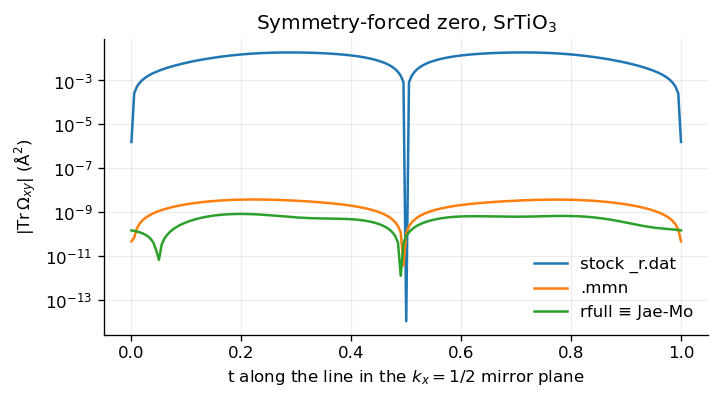

,C4z,Mx
mmn,6.0e-10,5.6e-10
rdat_ndegen_applied,5.2e-10,5.1e-10


Jae-Mo vs .mmn, relative L2 of Tr Ω on the 8³ mesh: {'xy': '38.0%', 'yz': '5.8%', 'zx': '5.8%'} | max |ΔE| = 0.0 eV


In [2]:
# Tr Omega_xy on the kx = 1/2 mirror plane of the SrTiO3 base, where symmetry forces it to zero
# (48 WF / 38 occupied). rfull is postw90's write_aa_r; Jae-Mo's _r.dat matches it to 1e-8 (below).
curves = np.load(RESULTS / "pr702_rdat_symmetry/symmetry_curves.npz")
routes = {"stock _r.dat": "rdat_direct [stock]", ".mmn": "mmn_pair", "rfull ≡ Jae-Mo": "rfull_pair"}

fig, ax = plt.subplots(figsize=(6.5, 3.2))
for label, key in routes.items():
    ax.semilogy(curves["t"], np.abs(curves[f"{key}|base|mirror_kx_half"]) + 1e-14, label=label)
ax.set(xlabel="t along the line in the $k_x=1/2$ mirror plane", ylabel=r"$|\mathrm{Tr}\,\Omega_{xy}|$ (Å$^2$)",
       title="Symmetry-forced zero, SrTiO$_3$")
ax.legend(frameon=False)
plt.show()

# C4z / Mx covariance of Tr Omega at 24 generic k (production trial04), and the .mmn vs Jae-Mo gap on the 8^3 mesh
s = json.loads((RESULTS / "rdat_ndegen_applied_symmetry_trial04_translinvfull/rdat_ndegen_applied_symmetry_summary.json").read_text())
display(pd.DataFrame({src: {op: s["offgrid_symmetry"][src][op]["relative_l2"] for op in ("C4z", "Mx")}
                      for src in ("mmn", "rdat_ndegen_applied")}).T.style.format("{:.1e}")
        .set_caption("Relative C4z / Mx residual of Tr Ω"))
gap = s["source_mesh_comparison"]
print("Jae-Mo vs .mmn, relative L2 of Tr Ω on the 8³ mesh:",
      {c: f"{v['relative_l2_difference']:.1%}" for c, v in gap["components"].items()},
      f"| max |ΔE| = {gap['max_abs_energy_difference_eV']} eV")

The stock file breaks the zero by about 1e‑2 Å². `.mmn`, `rfull` and Jae-Mo's file all hold it at the 1e‑9 level.
Jae-Mo's `_r.dat` also matches an `rfull` export we built independently with postw90, to 1e‑8. Two separate Fortran implementations give the same answer.

It is not the same as `.mmn`, though. H(k) is identical (ΔE = 0), but Tr Ω differs by about 6% (yz, zx) and 38% (xy) on the 8³ mesh.
These are two finite-mesh discretizations of the same continuum connection (the "rfull" and "mmn" families), and they need not agree at 8³.

**Born charges (Ti in SrTiO₃, trial 03, 48 WF):** the stock file was 3.9% off DFPT. The `rfull` formula, which is the one Jae-Mo writes, is 0.6% off.

In [3]:
born = pd.read_csv(RESULTS / "convention_symmetry/born_charge_comparison.csv")
born = born[(born.trial == "c") & (born.nk == 16)].set_index("convention")["z_total_zz"]
mixed = json.loads((RESULTS / "mixed_born/mixed_born_validation_summary.json").read_text())
dfpt = mixed["DFPT_benchmarks"]["Ti_trial03"]["DFPT"]
zstar = pd.Series({
    "stock _r.dat (before)": born["rdat_direct"],
    "rfull ≡ Jae-Mo (now)": born["mmn_pair"] + mixed["position_discretization_sensitivity"]["Ti_trial03_rfull_minus_mmn_Zstar"],
    ".mmn": born["mmn_pair"],
})
display(pd.DataFrame({"Z*_zz": zstar, "vs DFPT": zstar / dfpt - 1})
        .style.format({"Z*_zz": "{:.3f}", "vs DFPT": "{:+.2%}"})
        .set_caption(f"Ti Z*_zz, interpolation nk = 16; DFPT = {dfpt:.3f}"))

,Z*_zz,vs DFPT
stock _r.dat (before),7.572,+3.89%
rfull ≡ Jae-Mo (now),7.333,+0.61%
.mmn,7.301,+0.17%


### New problem: the base and displaced models break Wigner–Seitz ties differently

`use_ws_distance` gives each hopping to the periodic image with the shortest bond, and splits it equally when images tie.
Wannier90 does this separately for each run, using that run's own Wannier centres.
The base is symmetric, so it has exact ties. In mode 1, 172 of the 176 centres move by more than the 1e‑5 Å tie tolerance, so a bond split (½, ½) in the base lands on one image in the mode.
Then (H_mode − H_base)/Δβ picks up a change of interpolant that grows like 1/Δβ.
This affects 1.4% of the H(R) entries and 5.5% of |ΔH|, and the `.mmn` route has it too.

Where it appears: for `.mmn` the images of a class are copies, so the term cancels exactly at the ab‑initio k-points.
The YIO mesh is 8³, so nk = 4 and 8 are unaffected and nk = 6, 10 and 12 are not.

**Fix (today):** `load_wannier_pair(shared_ws_centres=True)` folds H(R) and A(R) of both structures on the base centres.
Afterwards `ws_pair_consistency` counts 0 changed entries.

In [4]:
def sweep(name):
    df = pd.read_csv(SWEEPS / name / "summary.csv").set_index("nk")
    base = [c for c in df if c.endswith("real") and ("base" in c or "beta0" in c) and "simpson" not in c][0]
    mode = [c for c in df if c.endswith("real") and ("mode" in c or "beta1" in c) and "simpson" not in c][0]
    return df[[base, mode]].set_axis(["base end", "mode end"], axis=1)

own, shared = sweep("nk_sweep_ext_ws_mmn").loc[4:12], sweep("nk_sweep_mmn_shared_ws")
ties = pd.concat({"own centres": own, "shared base centres": shared}, axis=1)
ties["on ab-initio mesh"] = [nk in (4, 8) for nk in ties.index]
ties["base-end change"] = shared["base end"] / own["base end"] - 1
display(ties.style.format("{:+.5f}", subset=list(ties.columns[:4])).format("{:+.1%}", subset=["base-end change"])
        .set_caption("YIO Γ₂⁻ mode 1, .mmn, dθ (rad/Å)"))

The base end doesn't change at nk = 4 and 8 and moves by 12–15% everywhere else, as predicted.
With shared centres the nk = 8 → 10 jump disappears, nk 10 → 12 changes by 0.2%, and the endpoint spread at nk = 12 drops from 8.4% to 2.8%.
**The tie inconsistency was a 15–18% error in the `.mmn` dθ.**

Jae-Mo's files can't be fixed after the fact. Under `transl_inv_full` each image carries its own phase exp(−i b·R/2), so tied images are not copies (they differ by up to a sign).
We re-implemented his formula from the `.chk` instead (`source="chk_transl_inv_full"`). It reproduces his `_r.dat` on 100% of the components to the six printed decimals, and it can fold on shared centres.

## 2. Quantum ESPRESSO bug in the Hubbard occupation symmetrizer

Last time we saw that the Hubbard occupation matrix was not symmetric across the four Ir sites. The cause is a bug in QE 7.5's `new_ns_nc` (`PW/src/new_ns.f90`), which only runs for noncollinear DFT+U.

For an invariant state the occupations transform as n(g·a) = U_g n(a) U_g†. The symmetrized occupation of atom `a` must therefore be built from the atom that g maps *into* `a`, which is `irt(invs(isym), na)`.
`new_ns_nc` applies the rotation the way the collinear routine does but uses `irt(isym, na)`, the atom that g maps `a` *to*.
The two coincide when g is its own inverse (E, inversion, twofold rotations, mirrors). They differ for every order‑3, 4 or 6 operation that permutes Hubbard atoms.
In our runs that is 28 of the 48 operations. They only appear because `symmetry_with_labels` treats the four Ir species as equivalent.

- **Fix:** two lines, `nb = irt(invs(isym), na)` (`calculations/qe_patches/`).
- **Proof:** we ported the QE routine to Python. As written, it is not a projector, and it cuts an exactly symmetric AIAO moment to 1/3. The patched version is exact to 1e‑15.
  A patched `pw.x` on the production input gives four identical Ir occupations. A small 4‑Fe reproducer shows the same split without the patch and none with it.
- **Upstream:** reported as [QE issue #887](https://gitlab.com/QEF/q-e/-/issues/887). The open draft MR !2512 attacks the same routine but is still wrong: it breaks 36 of our 48 terms.

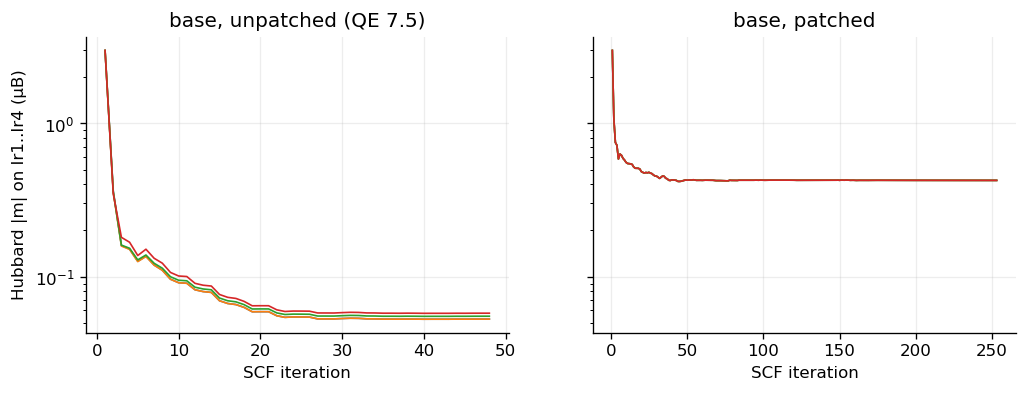

In [5]:
IR = {5: (-1, -1, -1), 6: (-1, 1, 1), 7: (1, -1, 1), 8: (1, 1, -1)}   # atom index -> local 3-fold axis


def hubbard_moments(path):
    # Hubbard-projected |m| and tilt off the 3-fold axis on Ir1..Ir4, one row per printed occupation block
    rows, block, atom = [], None, None
    for line in open(path):
        if "HUBBARD OCCUPATIONS" in line:
            if block: rows.append(block)
            block = {}
        elif "-- ATOM" in line and "---" in line:
            atom = int(line.split("ATOM")[1].split("-")[0])
        elif "Atomic magnetic moment mx, my, mz" in line and block is not None and atom in IR:
            block[atom] = np.array(line.split("=")[1].split(), float)
    rows.append(block)
    rows = [b for b in rows if b and all(a in b for a in IR)]
    mag = np.array([[np.linalg.norm(b[a]) for a in IR] for b in rows])
    tilt = np.array([[np.degrees(np.arccos(min(1, abs(b[a] @ n) / np.linalg.norm(b[a]) / np.sqrt(3))))
                      for a, n in IR.items()] for b in rows])
    return mag, tilt


def sphere_moments(path):
    # |m| integrated in the Ir spheres (the pw.x "report" block), last iteration
    last, atom = {}, None
    for line in open(path):
        if "atom number" in line:
            atom = int(line.split()[2])
        elif line.strip().startswith("magnetization :") and atom in IR:
            last[atom] = np.linalg.norm(np.array(line.split(":")[1].split(), float))
    return np.array([last[a] for a in IR])


def gap_and_energy(folder):
    energy = [float(l.split("=")[1].split()[0]) for l in open(folder / "Y2Ir2O7.scf.out") if l.startswith("!")][-1]
    edges = [l for l in open(folder / "Y2Ir2O7.nscf.out") if "highest occupied, lowest unoccupied" in l][-1]
    homo, lumo = map(float, edges.split(":")[1].split())
    return lumo - homo, energy


# SCF folders: unpatched QE 7.5 (production so far) and the patched rerun (QE 7.6 build with the fix)
RUNS = {
    "base": (DATA / "Y2Ir2O7/base/soc/u_3.0/output/178382bc889",
             DATA / "Y2Ir2O7/base/soc/u_3.0/output/192344"),
    "Γ₂⁻ mode 1": (DATA / "Y2Ir2O7/phonon/GM2-/mode1/Q_0.01A/output/178365bc889",
                   DATA / "Y2Ir2O7/phonon/GM2-/mode1/Q_0.01A/output/192345"),
    "Γ₂⁻ mode 2": (DATA / "Y2Ir2O7/phonon/GM2-/mode2/Q_0.01A/output/178380bc889",
                   DATA / "Y2Ir2O7/phonon/GM2-/mode2/Q_0.01A/output/192346"),
}

rows = {}
for structure, folders in RUNS.items():
    for label, folder in zip(("unpatched", "patched"), folders):
        mag, tilt = hubbard_moments(folder / "Y2Ir2O7.scf.out")
        gap, energy = gap_and_energy(folder)
        rows[(structure, label)] = {
            "Hubbard |m| (μB)": mag[-1].mean(), "spread": np.ptp(mag[-1]) / mag[-1].mean(), "max tilt (deg)": tilt[-1].max(),
            "sphere |m| (μB)": sphere_moments(folder / "Y2Ir2O7.scf.out").mean(), "NSCF gap (eV)": gap, "E (Ry)": energy}
table = pd.DataFrame(rows).T
display(table.style.format({"Hubbard |m| (μB)": "{:.3f}", "spread": "{:.2%}", "max tilt (deg)": "{:.2f}",
                            "sphere |m| (μB)": "{:.3f}", "NSCF gap (eV)": "{:.3f}", "E (Ry)": "{:.5f}"})
        .set_caption("Ir moments, band gap and energy: unpatched vs patched pw.x (last SCF iteration)"))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, (label, folder) in zip(axes, zip(("unpatched (QE 7.5)", "patched"), RUNS["base"])):
    mag, _ = hubbard_moments(folder / "Y2Ir2O7.scf.out")
    ax.semilogy(np.arange(1, len(mag) + 1), mag, lw=1)
    ax.set(title=f"base, {label}", xlabel="SCF iteration")
axes[0].set_ylabel("Hubbard |m| on Ir1..Ir4 (μB)")
plt.show()

**Patched reruns (converged; base, Γ₂⁻ mode 1 and mode 2).** Same inputs, `symmetry_with_labels` still on, so all 48 operations of the base are
active (24 for the modes). The only change is the `pw.x` (a QE 7.6 build with the fix, run from the job folder).
- Without the patch the four Ir drift apart by about 9% and tilt up to 5° off their 3‑fold axes. With it they are identical at every iteration
  (0.00% spread, 0.00° tilt), in all three structures.
- The Ir moment is much larger: 0.30 μB in the Ir spheres against 0.12 (2.4×), and 0.42 against 0.05 μB Hubbard-projected (8×). It is
  still all-in-all-out, with zero net moment.
- The gap on the NSCF mesh opens from 0.42 to 0.76 eV, and the total energy is 1.23 eV per cell lower.
- The displaced structures change the same way, so the finite difference compares two consistent states again.

So the unpatched runs were not just slightly asymmetric: they had a much weaker Ir moment and a gap about half as large.

**Effect on the curvature.** The magnetic point-group test of the YIO Berry curvature (176 WF, 156 occupied) has a floor of 4–14% of the typical curvature on the true symmetries.
A deliberately broken control reaches about 190%, so the test does resolve symmetry. The floor is almost the same for `.mmn` and Jae-Mo, which means it comes from the shared H(R), i.e. from the DFT.
The same test on SrTiO₃, which has no Hubbard U, holds to 5e‑10 (section 1).

In [6]:
tests = {"base inversion": "base_inversion", "base z axis (Ω = 0)": "base_mirror_intersection",
         "mode 1 C2z": "mode1_C2z", "mode 1 C3[111]": "mode1_C3_111", "mode 1 MxyT": "mode1_MxyT",
         "mode 1 S4zT": "mode1_S4zT", "control: base S4z without T": "base_S4z_control",
         "control: mode 1 S4z without T": "mode1_S4z_control"}
floor = {}
for route, folder in {".mmn": "magnetic_symmetry", "Jae-Mo": "magnetic_symmetry_jaemo"}.items():
    m = pd.read_csv(RESULTS / folder / "metrics.csv")
    m = m[m.part == "total"].set_index("test")["relative_residual"]
    floor[route] = {label: m[key] for label, key in tests.items()}
display(pd.DataFrame(floor).style.format("{:.1%}")
        .set_caption("YIO Tr Ω symmetry residual / typical |Ω| (unpatched QE)"))

,.mmn,Jae-Mo
base inversion,7.9%,9.7%
base z axis (Ω = 0),4.9%,7.6%
mode 1 C2z,13.3%,13.8%
mode 1 C3[111],13.1%,12.6%
mode 1 MxyT,4.9%,6.6%
mode 1 S4zT,6.3%,8.1%
control: base S4z without T,193.2%,191.4%
control: mode 1 S4z without T,196.4%,191.9%


The table above is still from the unpatched DFT. Next: Wannierize the patched runs (trial_02, same windows), rerun dθ, and repeat this
table to check that the 4–14% floor is gone.

## 3. New ∂θ/∂Q for YIO

Γ₂⁻ mode 1, Q = 0.01 Å, 176 WF / 156 occupied, U = 3 eV, frozen Wannier gauge. H(k) is the same in every row, so the rows differ only in A(R) and in the Wigner–Seitz rule.
"Base end" and "mode end" are the two endpoint estimates of the one finite difference. Their spread tests linearity, not validity.

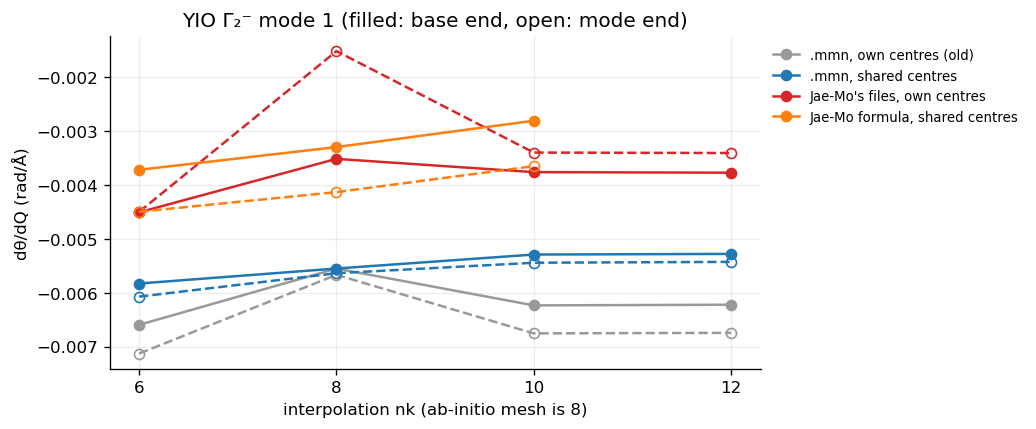

Jae-Mo / .mmn at nk = 10, shared centres: {'base end': 0.53, 'mode end': 0.67}


In [7]:
routes = {".mmn, own centres (old)": "nk_sweep_ext_ws_mmn",
          ".mmn, shared centres": "nk_sweep_mmn_shared_ws",
          "Jae-Mo's files, own centres": "nk_sweep_ext_ndegen",
          "Jae-Mo formula, shared centres": "nk_sweep_tif_shared_ws"}
dth = {label: sweep(name).loc[4:12] for label, name in routes.items()}

fig, ax = plt.subplots(figsize=(7, 3.6))
for (label, df), color in zip(dth.items(), ["0.6", "C0", "C3", "C1"]):
    df = df.loc[6:]
    ax.plot(df.index, df["base end"], "o-", color=color, label=label)
    ax.plot(df.index, df["mode end"], "o--", color=color, mfc="none")
ax.set(xlabel="interpolation nk (ab-initio mesh is 8)", ylabel="dθ/dQ (rad/Å)", xticks=[6, 8, 10, 12],
       title="YIO Γ₂⁻ mode 1 (filled: base end, open: mode end)")
ax.legend(frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

table = pd.concat(dth, axis=1).loc[[8, 10, 12]]
display(table.style.format("{:+.5f}", na_rep="—").set_caption("dθ/dQ (rad/Å)"))
ratio = dth["Jae-Mo formula, shared centres"].loc[10] / dth[".mmn, shared centres"].loc[10]
print("Jae-Mo / .mmn at nk = 10, shared centres:", ratio.round(2).to_dict())

- **`.mmn`, shared centres: −0.0053 / −0.0054 rad/Å**, converged to 0.2% (nk 10 → 12), with a 3% endpoint spread. This is the current best number.
- **Jae-Mo formula, shared centres:** same sign, but 0.53 / 0.67 of `.mmn` at nk = 10. It is still drifting with nk (−11%, −15% per step) and its endpoints differ by 20–30%.
  Without the shared rule, Jae-Mo's files are dominated by tie errors even on the ab‑initio mesh.
- When both formulas are built from the same `.chk` with the same H(R), rule and code, the gap stays. It comes from the A(R) formula itself: the k-space phase, the real-space exp(−i b·R/2), and how Hermiticity is imposed.
  Only a denser ab‑initio mesh can tell which family is right.
- `_r.dat` prints six decimals, and that rounding alone costs about 3% of dθ. The rounding errors are independent in base and mode and get divided by Δβ = 0.01. Building from the `.chk` avoids it.

**All of these numbers come from the unpatched DFT. None is final;** the patched SCF and NSCF are done (section 2), the Wannier stage is next.

## Next steps

- **Done (09‑24):** patched SCF and NSCF of the YIO base and Γ₂⁻ modes 1 and 2. Ir moments symmetric, 0.30 μB, gap 0.76 eV.
- **Next:** Wannierize the patched runs (trial_02), rerun dθ with `.mmn` + shared centres, and repeat the curvature symmetry test.
  With the stronger moment and the wider gap, recheck how U maps onto the gap and the moment.
- **Position matrix:** run Jae-Mo's formula to nk ≥ 12, and use a denser ab‑initio mesh to decide between the `.mmn` and `rfull` families.
- **Wigner–Seitz ties:** a second amplitude (Δβ) to confirm the 1/Δβ scaling and test linearity. This needs a new displaced structure.
- **MnBi₂Te₄:** the T₂⁻ inputs trigger the same QE bug (two order‑6 operations swap the Mn atoms). Regenerate them on the precise cell and rerun with patched QE. The paper's 10 rad/Å still comes from the legacy driver.

Details: `notes/progress/2026-09-16_jaemo_rdat_production_closure.md`, `notes/progress/2026-09-23_ws_ties_in_beta_derivative.md`, `notes/progress/2026-09-21_qe_new_ns_nc_bug.md`, `notes/progress/2026-09-21_yio_symmetry.md`.